### 使用gpu

In [6]:
# 检查安装
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")  # 如果显示 False，就是用 CPU

PyTorch version: 2.11.0+cu130
CUDA available: True


In [7]:
import torch
print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")
print(f"GPU 数量: {torch.cuda.device_count()}")
print(f"GPU 名称: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

PyTorch 版本: 2.11.0+cu130
CUDA 可用: True
GPU 数量: 1
GPU 名称: NVIDIA GeForce RTX 3060 Laptop GPU


### 导入所有库

In [54]:
# Cell 2: 导入所有需要的库
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import os

# 设置随机种子，确保结果可复现
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 创建必要的文件夹
os.makedirs('results', exist_ok=True)
os.makedirs('report', exist_ok=True)

Using device: cuda


### 加载 CIFAR-10 数据

In [55]:
# Cell 3: 修改为不包含 ToTensor
simple_transform_for_display = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

# 用于显示的 dataset：返回 Tensor，可以正常显示
train_dataset_display = CIFAR10(root='./data', train=True, download=True, transform=simple_transform_for_display)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=simple_transform_for_display)

# 用于增强测试的 dataset：返回 PIL Image（不包含 ToTensor）
pil_transform = transforms.Compose([
    transforms.ToTensor()  # 这个先不包含，我们后面手动处理
])
# 更简单的方式：直接用 None
train_dataset_pil = CIFAR10(root='./data', train=True, download=True, transform=None)

### CIFAR-10 的图片分辨率只有 32×32 像素，模糊

In [56]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

# 重新加载数据
simple_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

train_dataset_full = CIFAR10(root='./data', train=True, download=True, transform=simple_transform)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=simple_transform)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print("✅ 变量重新定义完成！")

✅ 变量重新定义完成！


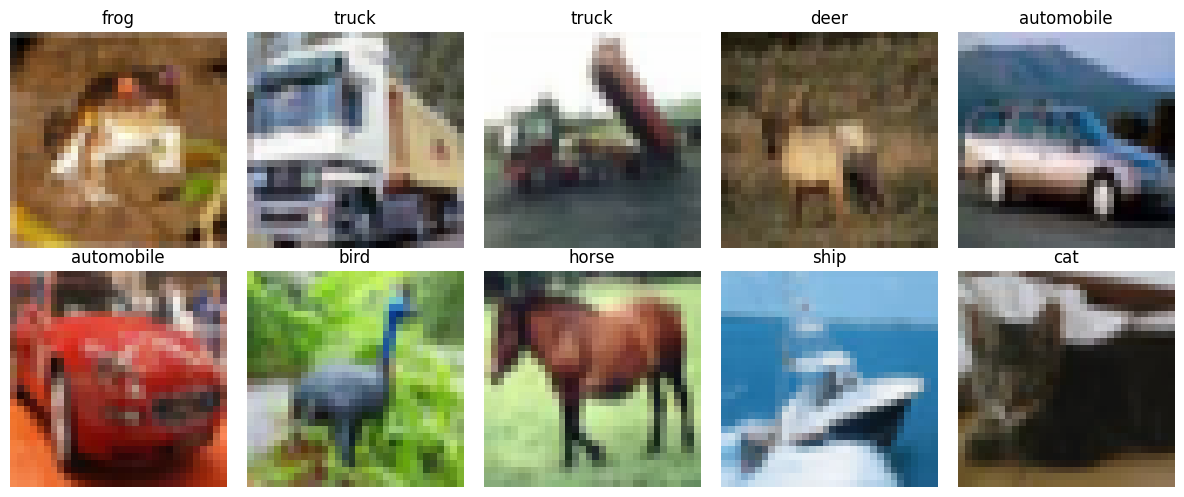

In [57]:
# Cell 4: 显示几张示例图片
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset_full[i]
    # 反归一化显示
    img_display = img.numpy().transpose(1, 2, 0)
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img_display = img_display * std + mean
    img_display = np.clip(img_display, 0, 1)
    ax.imshow(img_display)
    ax.set_title(class_names[label])
    ax.axis('off')
plt.tight_layout()
plt.savefig('report/cifar10_samples.png')
plt.show()

### 实现数据增强（核心组件 1）

In [58]:
# Cell 5: 定义 SimCLR 数据增强类
class SimCLRDataAugmentation:
    """
    SimCLR 数据增强模块
    对同一张图片生成两个不同的增强视图
    """
    def __init__(self, image_size=32, color_strength=0.5):
        """
        Args:
            image_size: 输入图像大小（CIFAR-10 是 32x32）
            color_strength: 颜色增强的强度
        """
        # 视图1的增强策略
        self.transform_view1 = transforms.Compose([
            transforms.RandomResizedCrop(size=image_size, scale=(0.2, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([
                transforms.ColorJitter(
                    brightness=0.8*color_strength,
                    contrast=0.8*color_strength,
                    saturation=0.8*color_strength,
                    hue=0.2*color_strength
                )
            ], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.4914, 0.4822, 0.4465],
                std=[0.2023, 0.1994, 0.2010]
            )
        ])
        
        # 视图2使用完全相同的策略（但随机采样是独立的）
        self.transform_view2 = transforms.Compose([
            transforms.RandomResizedCrop(size=image_size, scale=(0.2, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([
                transforms.ColorJitter(
                    brightness=0.8*color_strength,
                    contrast=0.8*color_strength,
                    saturation=0.8*color_strength,
                    hue=0.2*color_strength
                )
            ], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.4914, 0.4822, 0.4465],
                std=[0.2023, 0.1994, 0.2010]
            )
        ])
    
    def __call__(self, x):
        """返回同一张图片的两个增强视图"""
        return self.transform_view1(x), self.transform_view2(x)

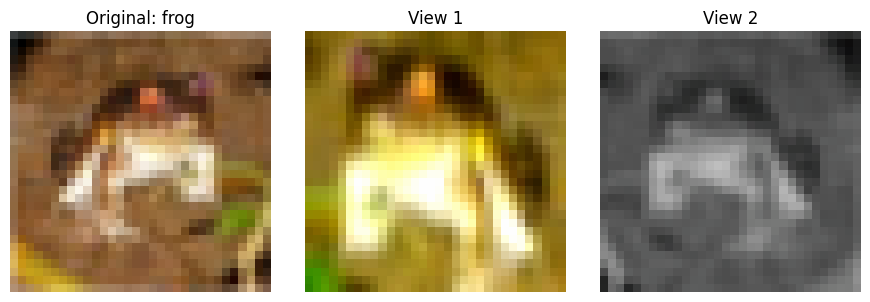

✅ 数据增强测试通过！


In [59]:
# Cell 6: 测试数据增强效果
augmentation = SimCLRDataAugmentation(image_size=32, color_strength=0.5)

# 从 train_dataset_pil 取图片（返回 PIL Image）
test_img_pil, label = train_dataset_pil[0]

# 生成两个视图
view1, view2 = augmentation(test_img_pil)

# 显示原始图片和两个增强视图
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

# 显示原始图片（PIL Image 直接显示）
axes[0].imshow(test_img_pil)
axes[0].set_title(f'Original: {class_names[label]}')
axes[0].axis('off')

# 视图1（Tensor，需要反归一化）
img1 = view1.numpy().transpose(1, 2, 0)
mean = np.array([0.4914, 0.4822, 0.4465])
std = np.array([0.2023, 0.1994, 0.2010])
img1 = img1 * std + mean
img1 = np.clip(img1, 0, 1)
axes[1].imshow(img1)
axes[1].set_title('View 1')
axes[1].axis('off')

# 视图2（同理）
img2 = view2.numpy().transpose(1, 2, 0)
img2 = img2 * std + mean
img2 = np.clip(img2, 0, 1)
axes[2].imshow(img2)
axes[2].set_title('View 2')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('report/augmentation_demo.png')
plt.show()
print("✅ 数据增强测试通过！")

### 实现编码器 (Encoder)

In [103]:
# Cell 7: Encoder - ResNet-18 (最终优化版)
import torch.nn as nn
import torchvision.models as models

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 加载 ResNet-18
        resnet = models.resnet18(weights=None)
        
        # 适配 CIFAR-10 32x32 输入
        resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        resnet.maxpool = nn.Identity()  # 去掉 maxpool
        
        # 去掉最后的全连接层，保留特征提取部分
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])
        self.out_dim = 512  # ResNet-18 输出 512 维

    def forward(self, x):
        x = self.encoder(x)
        return x.view(x.size(0), -1)  # 展平

# 测试
encoder = Encoder()
test_input = torch.randn(4, 3, 32, 32)
test_output = encoder(test_input)
print(f"输入形状: {test_input.shape}")
print(f"输出形状: {test_output.shape}")  # 应该是 [4, 512]
print(f"✅ Encoder (ResNet-18) 测试通过！输出维度: {encoder.out_dim}")

输入形状: torch.Size([4, 3, 32, 32])
输出形状: torch.Size([4, 512])
✅ Encoder (ResNet-18) 测试通过！输出维度: 512


### 实现投影头 (Projection Head)

In [104]:
# Cell 8: Projection Head (标准 SimCLR)
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=512, output_dim=128):  # ← input_dim 改成 512
        super(ProjectionHead, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.net(x)

# 测试
projection_head = ProjectionHead(input_dim=512, hidden_dim=512, output_dim=128)
test_h = torch.randn(4, 512)  # ← 改成 512
test_z = projection_head(test_h)
print(f"输入形状: {test_h.shape}")
print(f"输出形状: {test_z.shape}")  # 应该是 [4, 128]
print("✅ 投影头测试通过！")

输入形状: torch.Size([4, 512])
输出形状: torch.Size([4, 128])
✅ 投影头测试通过！


### 组装完整 SimCLR 模型

In [105]:
# Cell 9: SimCLR 模型（简化版）
class SimCLR(nn.Module):
    def __init__(self, encoder, projection_head):
        super().__init__()
        self.encoder = encoder
        self.projection_head = projection_head

    def forward(self, x):
        h = self.encoder(x)
        z = self.projection_head(h)
        return z

    def get_representation(self, x):
        """获取表征向量（用于 linear probe）"""
        with torch.no_grad():
            return self.encoder(x)

# 创建模型
encoder = Encoder()  # ← 使用新的 ResNet-18 Encoder
projection_head = ProjectionHead(input_dim=512, hidden_dim=512, output_dim=128)
model = SimCLR(encoder, projection_head).to(device)

print("✅ SimCLR 模型创建成功！")
print(f"编码器参数量: {sum(p.numel() for p in encoder.parameters()):,}")
print(f"投影头参数量: {sum(p.numel() for p in projection_head.parameters()):,}")
print(f"总参数量: {sum(p.numel() for p in model.parameters()):,}")

# 测试
test_x = torch.randn(8, 3, 32, 32).to(device)
z = model(test_x)
print(f"测试输出形状: {z.shape}")  # 应该是 [8, 128]

✅ SimCLR 模型创建成功！
编码器参数量: 11,168,832
投影头参数量: 328,320
总参数量: 11,497,152
测试输出形状: torch.Size([8, 128])


### 实现 NT-Xent 损失

In [106]:
# Cell 10: NT-Xent Loss (优化稳定版)
class NTXentLoss:
    def __init__(self, temperature=0.5):
        self.temperature = temperature

    def __call__(self, z):
        # L2 归一化
        z = F.normalize(z, dim=1)
        
        # 计算相似度矩阵
        N = z.shape[0]
        sim = torch.matmul(z, z.T) / self.temperature
        
        # 正样本配对: i <-> i + N//2
        labels = torch.arange(N, device=z.device)
        labels = (labels + N // 2) % N
        
        # 移除自身相似度（对角线设为 -inf）
        mask = torch.eye(N, device=z.device).bool()
        sim = sim.masked_fill(mask, -1e9)
        
        # 交叉熵损失
        loss = F.cross_entropy(sim, labels)
        return loss

# 测试
criterion = NTXentLoss(temperature=0.5)
test_z = torch.randn(8, 128)
test_loss = criterion(test_z)
print(f"测试损失值: {test_loss.item():.4f}")
print("✅ NT-Xent Loss 测试通过！")

测试损失值: 1.9197
✅ NT-Xent Loss 测试通过！


In [107]:
# Cell 10.5: TwoCropTransform
class TwoCropTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return self.transform(x), self.transform(x)

print("✅ TwoCropTransform 定义完成！")

✅ TwoCropTransform 定义完成！


### 准备预训练数据

In [108]:
import torchvision.transforms as transforms
pretrain_transform = transforms.Compose([
    transforms.RandomResizedCrop(32),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.5,0.5,0.5,0.2),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor()
])

class TwoCropTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return self.transform(x), self.transform(x)

In [109]:
# Cell 11: 数据增强 + 数据加载（最终优化版）
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import Subset, DataLoader
import numpy as np

num_pretrain = 3000
batch_size = 64  # ← 从 16 提升到 64！

# 单视图增强（更强的增强）
simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(0.8, 0.8, 0.8, 0.2)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], 
                         std=[0.2023, 0.1994, 0.2010])
])

# TwoCropTransform 生成双视图
train_dataset = CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=TwoCropTransform(simclr_transform)
)

# 随机选择子集
if num_pretrain < len(train_dataset):
    indices = np.random.choice(len(train_dataset), num_pretrain, replace=False)
    train_subset = Subset(train_dataset, indices)
else:
    train_subset = train_dataset

# DataLoader（batch_size 提升到 64）
train_loader = DataLoader(
    train_subset, 
    batch_size=batch_size,  # ← 64
    shuffle=True, 
    num_workers=0,
    drop_last=True
)

print(f"预训练使用 {len(train_subset)} 张图片")
print(f"每个 epoch 有 {len(train_loader)} 个 batch")
print(f"Batch size: {batch_size}")
print("✅ 预训练数据准备完成！")

预训练使用 3000 张图片
每个 epoch 有 46 个 batch
Batch size: 64
✅ 预训练数据准备完成！


In [110]:
# 验证数据加载器
print("验证数据加载器输出格式...")

for batch_idx, (x, _) in enumerate(train_loader):
    # DataLoader 返回的 x 可能是 list 或 tuple，检查长度是否为 2
    if isinstance(x, (list, tuple)) and len(x) == 2:
        view1, view2 = x
        print(f"Batch {batch_idx}: view1.shape={view1.shape}, view2.shape={view2.shape}")
    else:
        print(f"x 的结构异常: {type(x)}，内容: {x}")
    if batch_idx >= 2:
        break
print("✅ 验证完成！")

验证数据加载器输出格式...
Batch 0: view1.shape=torch.Size([64, 3, 32, 32]), view2.shape=torch.Size([64, 3, 32, 32])
Batch 1: view1.shape=torch.Size([64, 3, 32, 32]), view2.shape=torch.Size([64, 3, 32, 32])
Batch 2: view1.shape=torch.Size([64, 3, 32, 32]), view2.shape=torch.Size([64, 3, 32, 32])
✅ 验证完成！


In [111]:
# 在 Cell 12 的开头添加
import torch
print(f"GPU 显存已分配: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"GPU 显存已缓存: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

GPU 显存已分配: 192.82 MB
GPU 显存已缓存: 2756.00 MB


In [112]:
# Cell 12: 预训练循环（最终优化版）
def pretrain(model, train_loader, epochs=50, lr=1e-3, temperature=0.5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    criterion = NTXentLoss(temperature=temperature)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Cosine LR Scheduler（加分项！）
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    loss_history = []
    model.train()
    
    print(f"开始预训练，共 {epochs} 个 epoch...")
    print("=" * 50)

    for epoch in range(epochs):
        total_loss = 0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        
        for batch_idx, (x, _) in enumerate(progress_bar):
            # x 是 (view1, view2) 元组
            x1, x2 = x[0].to(device), x[1].to(device)
            x_combined = torch.cat([x1, x2], dim=0)
            
            z = model(x_combined)
            loss = criterion(z)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        scheduler.step()  # ← 更新学习率
        
        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}: loss={avg_loss:.4f}, lr={current_lr:.6f}")
    
    print("=" * 50)
    print("✅ 预训练完成！")
    
    return loss_history

# 执行预训练（50 轮）
loss_history = pretrain(
    model=model,
    train_loader=train_loader,
    epochs=50,  # ← 从 20 提升到 50
    lr=1e-3,
    temperature=0.5
)

开始预训练，共 50 个 epoch...


Epoch 1/50: 100%|██████████| 46/46 [00:06<00:00,  6.91it/s, loss=4.5212]


Epoch 1: loss=4.6769, lr=0.000999


Epoch 2/50: 100%|██████████| 46/46 [00:06<00:00,  7.01it/s, loss=4.8706]


Epoch 2: loss=4.6703, lr=0.000996


...

Epoch 48: loss=3.7820, lr=0.000004


Epoch 49/50: 100%|██████████| 46/46 [00:06<00:00,  6.99it/s, loss=3.7044]


Epoch 49: loss=3.7804, lr=0.000001


Epoch 50/50: 100%|██████████| 46/46 [00:06<00:00,  6.98it/s, loss=3.8856]

Epoch 50: loss=3.7799, lr=0.000000
✅ 预训练完成！


✅ 模型已保存到 results/simclr_model.pt


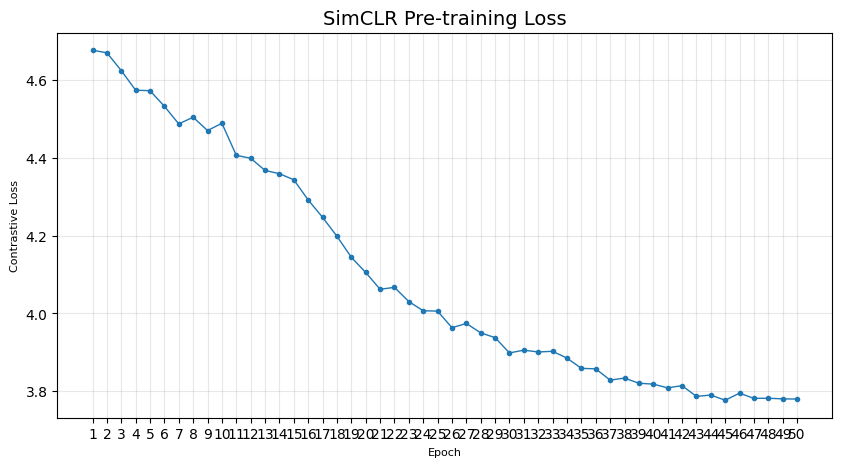

✅ Loss 曲线已保存到 report/loss_curve.png


In [113]:
# Cell 13: 保存模型和绘制 Loss 曲线
import matplotlib.pyplot as plt

# 保存模型
torch.save({
    'encoder_state_dict': model.encoder.state_dict(),
    'projection_head_state_dict': model.projection_head.state_dict(),
    'loss_history': loss_history,
    'config': {
        'num_pretrain': 3000,
        'epochs': 5,
        'batch_size': 16,
        'temperature': 0.2
    }
}, 'results/simclr_model.pt')
print("✅ 模型已保存到 results/simclr_model.pt")

# 绘制 Loss 曲线
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', linewidth=1, markersize=3)
plt.xlabel('Epoch', fontsize=8)
plt.ylabel('Contrastive Loss', fontsize=8)
plt.title('SimCLR Pre-training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(loss_history) + 1))
plt.savefig('report/loss_curve.png', dpi=150)
plt.show()
print("✅ Loss 曲线已保存到 report/loss_curve.png")

冻结你预训练好的编码器（Encoder）——它的权重不再更新

在编码器后面接一个新的线性分类器（只有一层全连接层）

只训练这个分类器，用 CIFAR-10 的标签来训练

在测试集上评估准确率

In [87]:
# 检查 test_dataset
print(f"test_dataset 长度: {len(test_dataset)}")
# 应该输出 10000，而不是 50000

test_dataset 长度: 10000


In [114]:
# Cell 14: Linear Probe 线性评估
def linear_evaluation(model, test_dataset, num_train_labels=1000, epochs=5, lr=1e-3):
    """
    线性评估：冻结编码器，训练线性分类器
    """
    # 1. 冻结编码器
    for param in model.encoder.parameters():
        param.requires_grad = False
    model.encoder.eval()
    
    # 2. 准备带标签的训练数据（使用简单的预处理，不要数据增强）
    simple_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
    ])
    
    train_dataset = CIFAR10(root='./data', train=True, download=True, transform=simple_transform)
    
    # 随机选择部分带标签数据
    num_train = min(num_train_labels, len(train_dataset))
    indices = np.random.choice(len(train_dataset), num_train, replace=False)
    train_subset = Subset(train_dataset, indices)
    train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2)
    
    # 准备测试数据
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)
    
    # 3. 创建线性分类器
    classifier = nn.Linear(512, 10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=lr)
    
    print(f"使用 {len(train_subset)} 张带标签图片训练线性分类器")
    print(f"测试集大小: {len(test_dataset)}")
    print(f"训练 {epochs} 个 epoch...")
    print("-" * 50)
    
    train_acc_history = []
    test_acc_history = []
    best_acc = 0.0
    
    for epoch in range(1, epochs + 1):
        # 训练
        classifier.train()
        correct = 0
        total = 0
        epoch_loss = 0.0
        
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}')
        for data, targets in progress_bar:
            data, targets = data.to(device), targets.to(device)
            
            # 提取特征（编码器已冻结）
            with torch.no_grad():
                features = model.encoder(data)
            
            outputs = classifier(features)
            loss = criterion(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })
        
        train_acc = 100.0 * correct / total
        train_acc_history.append(train_acc)
        
        # 测试
        classifier.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, targets in test_loader:
                data, targets = data.to(device), targets.to(device)
                features = model.encoder(data)
                outputs = classifier(features)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        
        test_acc = 100.0 * correct / total
        test_acc_history.append(test_acc)
        
        if test_acc > best_acc:
            best_acc = test_acc
        
        print(f'Epoch {epoch}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%')
    
    print("-" * 50)
    print(f"✅ 最佳测试准确率: {best_acc:.2f}%")
    
    return best_acc, train_acc_history, test_acc_history, classifier

# 执行线性评估
best_acc, train_acc_history, test_acc_history, classifier = linear_evaluation(
    model=model,
    test_dataset=test_dataset,
    num_train_labels=1000,  # 至少 1000，可以改成 2000 或 5000
    epochs=50,
    lr=1e-3
)

使用 1000 张带标签图片训练线性分类器
测试集大小: 10000
训练 50 个 epoch...
--------------------------------------------------


Epoch 1/50: 100%|██████████| 16/16 [00:10<00:00,  1.55it/s, loss=2.0557, acc=23.30%]


Epoch 1: Train Acc=23.30%, Test Acc=33.79%


Epoch 2/50: 100%|██████████| 16/16 [00:06<00:00,  2.32it/s, loss=1.6831, acc=33.90%]


Epoch 2: Train Acc=33.90%, Test Acc=34.94%


...

Epoch 48: Train Acc=44.90%, Test Acc=39.38%


Epoch 49/50: 100%|██████████| 16/16 [00:06<00:00,  2.43it/s, loss=1.4994, acc=43.10%]


Epoch 49: Train Acc=43.10%, Test Acc=39.01%


Epoch 50/50: 100%|██████████| 16/16 [00:06<00:00,  2.43it/s, loss=1.4016, acc=43.80%]


Epoch 50: Train Acc=43.80%, Test Acc=38.90%
--------------------------------------------------
✅ 最佳测试准确率: 40.10%


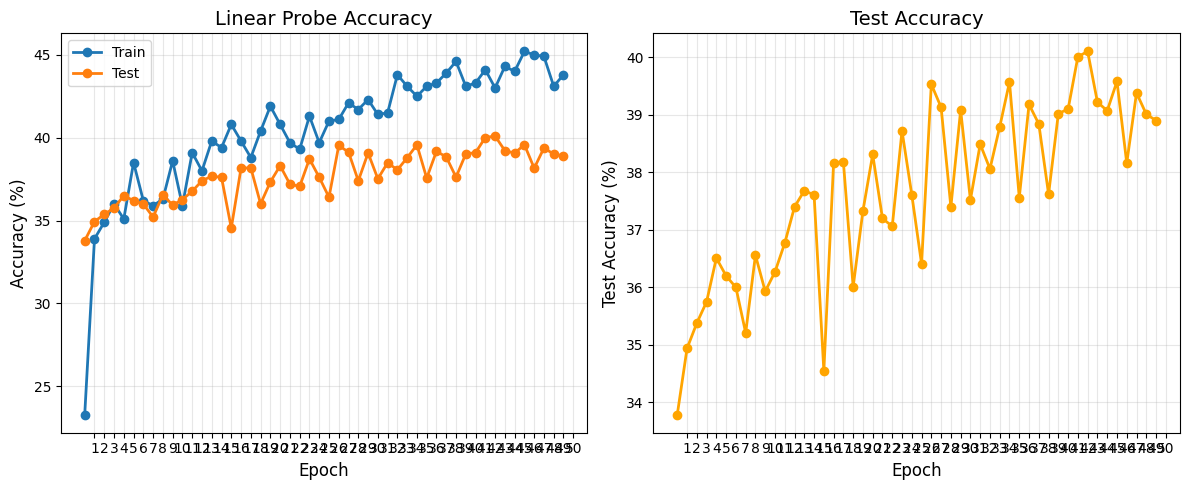

✅ 评估曲线已保存到 report/eval_accuracy.png


In [115]:
# Cell 15: 绘制评估结果
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_acc_history, marker='o', label='Train', linewidth=2)
plt.plot(test_acc_history, marker='o', label='Test', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Linear Probe Accuracy', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(train_acc_history) + 1))

plt.subplot(1, 2, 2)
plt.plot(test_acc_history, marker='o', color='orange', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Test Accuracy', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(test_acc_history) + 1))

plt.tight_layout()
plt.savefig('report/eval_accuracy.png', dpi=150)
plt.show()
print("✅ 评估曲线已保存到 report/eval_accuracy.png")

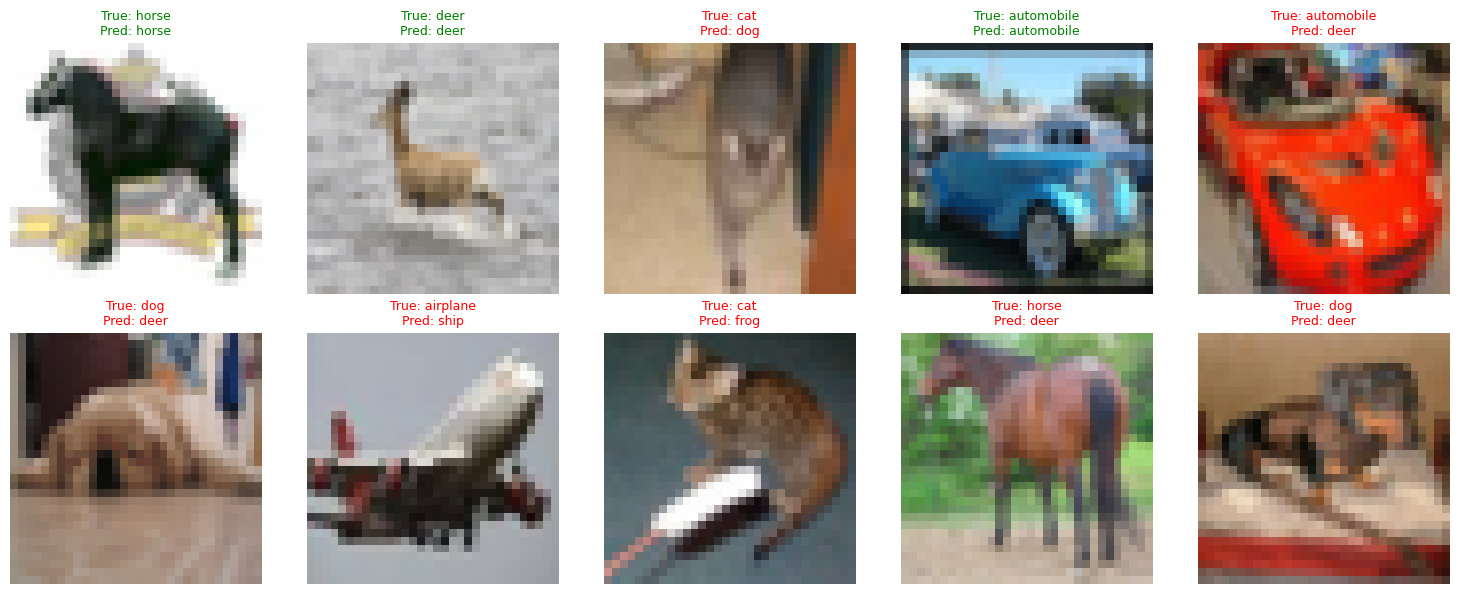

正确率: 3/10 = 30.0%

详细结果:
  1. True:        horse | Pred:        horse ✅
  2. True:         deer | Pred:         deer ✅
  3. True:          cat | Pred:          dog ❌
  4. True:   automobile | Pred:   automobile ✅
  5. True:   automobile | Pred:         deer ❌
  6. True:          dog | Pred:         deer ❌
  7. True:     airplane | Pred:         ship ❌
  8. True:          cat | Pred:         frog ❌
  9. True:        horse | Pred:         deer ❌
  10. True:          dog | Pred:         deer ❌


In [116]:
# Cell 16: 展示测试图片的预测结果
def show_predictions(model, classifier, test_dataset, num_samples=10):
    """
    随机选择测试图片，显示真实标签和预测标签
    """
    model.encoder.eval()
    classifier.eval()
    
    # 随机选择样本
    indices = random.sample(range(len(test_dataset)), num_samples)
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    correct_count = 0
    results = []
    
    with torch.no_grad():
        for idx, img_idx in enumerate(indices):
            img, label = test_dataset[img_idx]
            img_tensor = img.unsqueeze(0).to(device)
            
            features = model.encoder(img_tensor)
            output = classifier(features)
            pred = output.argmax(dim=1).item()
            
            # 显示图像
            img_display = img.numpy().transpose(1, 2, 0)
            mean = np.array([0.4914, 0.4822, 0.4465])
            std = np.array([0.2023, 0.1994, 0.2010])
            img_display = img_display * std + mean
            img_display = np.clip(img_display, 0, 1)
            
            axes[idx].imshow(img_display)
            axes[idx].axis('off')
            
            is_correct = (pred == label)
            color = 'green' if is_correct else 'red'
            axes[idx].set_title(
                f'True: {class_names[label]}\nPred: {class_names[pred]}',
                color=color,
                fontsize=9
            )
            
            if is_correct:
                correct_count += 1
            
            results.append({
                'image_idx': img_idx,
                'true_label': class_names[label],
                'pred_label': class_names[pred],
                'correct': is_correct
            })
    
    plt.tight_layout()
    plt.savefig('report/predictions.png', dpi=150)
    plt.show()
    
    print(f"正确率: {correct_count}/{num_samples} = {100.0*correct_count/num_samples:.1f}%")
    print("\n详细结果:")
    for i, r in enumerate(results):
        mark = '✅' if r['correct'] else '❌'
        print(f"  {i+1}. True: {r['true_label']:>12} | Pred: {r['pred_label']:>12} {mark}")
    
    return results

# 显示预测结果
results = show_predictions(model, classifier, test_dataset, num_samples=10)

In [19]:
# Cell 17: 总结实验结果
print("=" * 60)
print("📊 SimCLR 实验总结")
print("=" * 60)

print(f"\n【预训练配置】")
print(f"  使用训练图像数: 3000")
print(f"  预训练 epoch: {len(loss_history)}")
print(f"  Batch size: 16")
print(f"  Temperature: 0.5")
print(f"  最终预训练 Loss: {loss_history[-1]:.4f}")

print(f"\n【Linear Probe 配置】")
print(f"  使用带标签图像数: 1000")
print(f"  Linear probe epoch: 5")
print(f"  最佳测试准确率: {best_acc:.2f}%")

print(f"\n【保存的文件】")
print(f"  模型: results/simclr_model.pt")
print(f"  Loss 曲线: report/loss_curve.png")
print(f"  评估曲线: report/eval_accuracy.png")
print(f"  预测样例: report/predictions.png")

# 保存结果到文本文件
with open('results/summary.txt', 'w') as f:
    f.write("SimCLR 实验总结\n")
    f.write("=" * 40 + "\n\n")
    f.write(f"预训练图像数: 3000\n")
    f.write(f"预训练 epoch: {len(loss_history)}\n")
    f.write(f"Batch size: 16\n")
    f.write(f"Temperature: 0.5\n")
    f.write(f"最终预训练 Loss: {loss_history[-1]:.4f}\n")
    f.write(f"Linear probe 图像数: 1000\n")
    f.write(f"Linear probe epoch: 5\n")
    f.write(f"最佳测试准确率: {best_acc:.2f}%\n")

print("\n✅ 所有结果已保存！")

📊 SimCLR 实验总结

【预训练配置】
  使用训练图像数: 3000


NameError: name 'loss_history' is not defined